In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import os

In [3]:
os.makedirs("charts", exist_ok=True)

print("Charts folder created successfully")

Charts folder created successfully


In [4]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
missing = df.isnull().sum()

print(missing)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (545, 13)


In [8]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({'yes':1,'no':0})

In [9]:
encoder = LabelEncoder()

df['furnishingstatus'] = encoder.fit_transform(
    df['furnishingstatus']
)

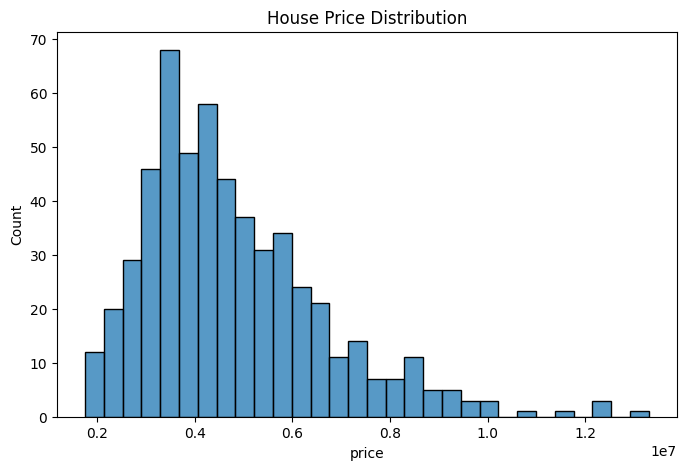

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30)

plt.title("House Price Distribution")

plt.savefig(
    "charts/01_price_distribution.png",
    bbox_inches="tight"
)

plt.show()

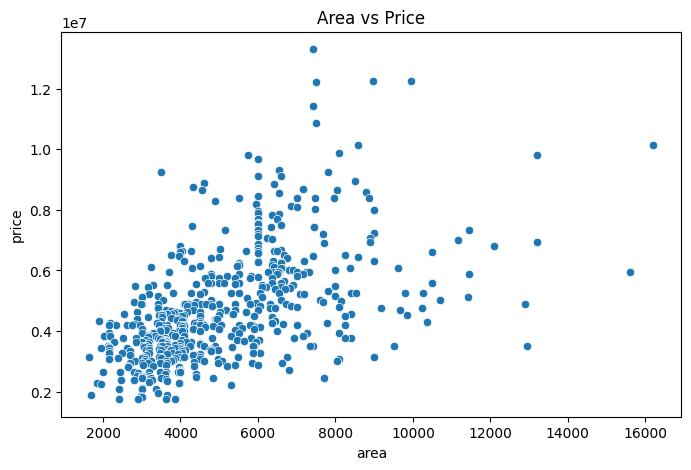

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['area'],
    y=df['price']
)

plt.title("Area vs Price")

plt.savefig(
    "charts/02_area_vs_price.png",
    bbox_inches="tight"
)

plt.show()

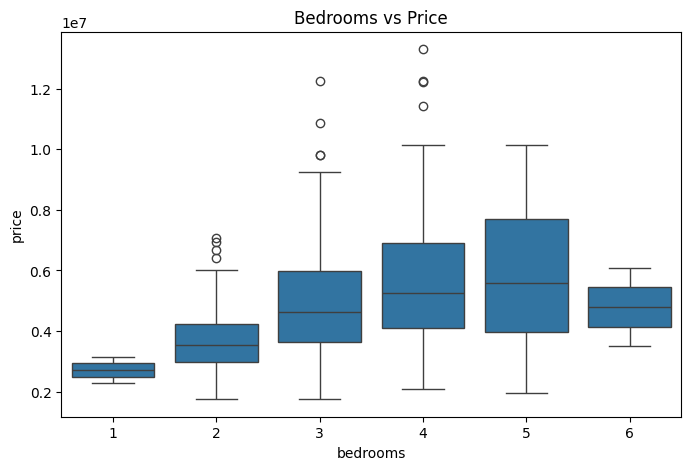

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['bedrooms'],
    y=df['price']
)

plt.title("Bedrooms vs Price")

plt.savefig(
    "charts/03_bedrooms_vs_price.png",
    bbox_inches="tight"
)

plt.show()

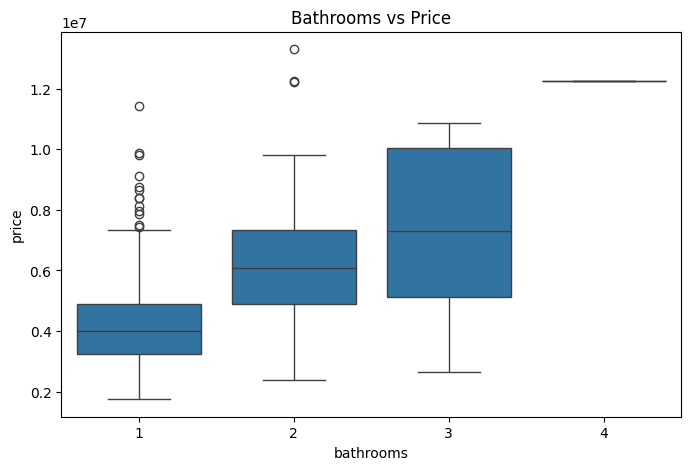

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['bathrooms'],
    y=df['price']
)

plt.title("Bathrooms vs Price")

plt.savefig(
    "charts/04_bathrooms_vs_price.png",
    bbox_inches="tight"
)

plt.show()

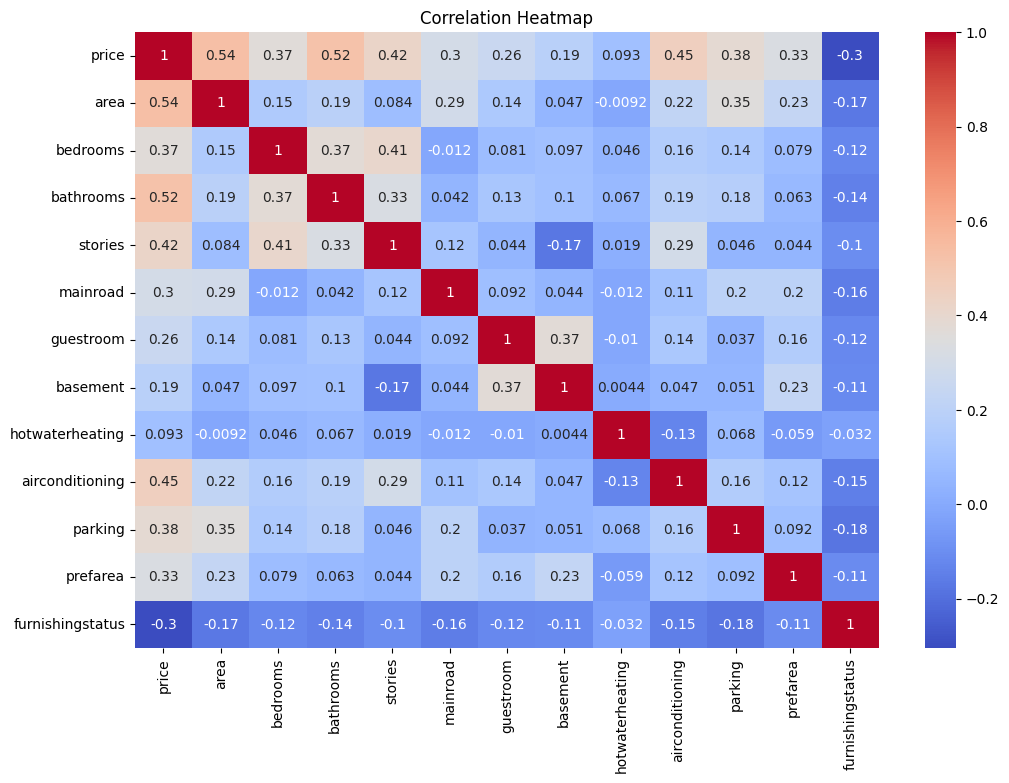

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/05_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [15]:
X = df.drop('price', axis=1)

y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


In [17]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [18]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [19]:
models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    print("\n", name)

    print("MAE :", round(mae,2))

    print("RMSE:", round(rmse,2))

    print("R2 :", round(r2,4))


 Linear Regression
MAE : 979679.69
RMSE: 1331071.42
R2 : 0.6495

 Decision Tree
MAE : 1222399.08
RMSE: 1639566.3
R2 : 0.4682

 Random Forest
MAE : 1016175.4
RMSE: 1395378.57
R2 : 0.6148


In [20]:
models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for name, pred in models.items():

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    print("\n", name)

    print("MAE :", round(mae,2))

    print("RMSE:", round(rmse,2))

    print("R2 :", round(r2,4))


 Linear Regression
MAE : 979679.69
RMSE: 1331071.42
R2 : 0.6495

 Decision Tree
MAE : 1222399.08
RMSE: 1639566.3
R2 : 0.4682

 Random Forest
MAE : 1016175.4
RMSE: 1395378.57
R2 : 0.6148


In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

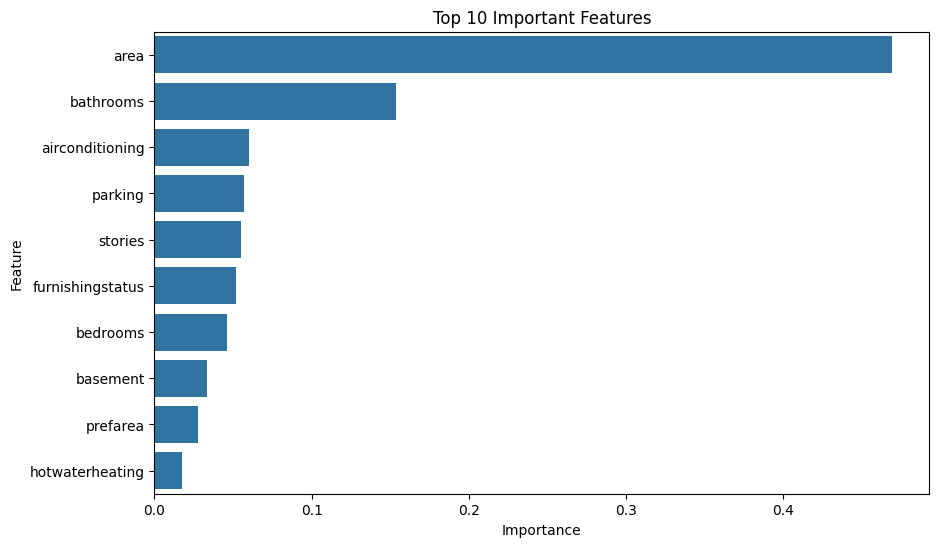

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.savefig(
    "charts/06_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

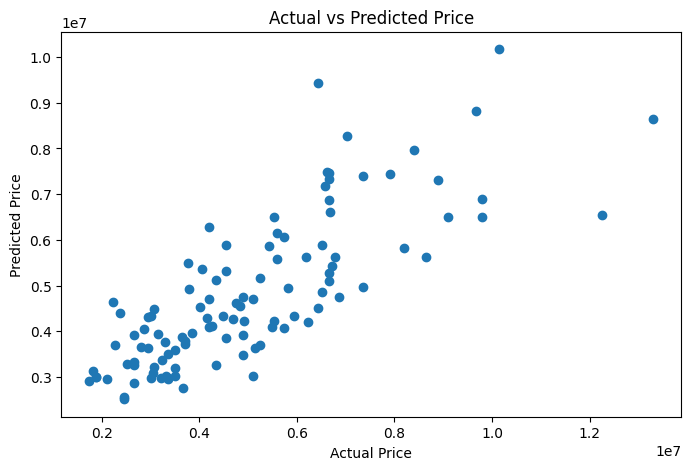

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Price"
)

plt.savefig(
    "charts/07_actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
sample_house = pd.DataFrame({

'area':[7500],
'bedrooms':[4],
'bathrooms':[3],
'stories':[2],
'mainroad':[1],
'guestroom':[1],
'basement':[1],
'hotwaterheating':[0],
'airconditioning':[1],
'parking':[2],
'prefarea':[1],
'furnishingstatus':[2]

})

In [25]:
prediction = rf.predict(sample_house)

print(
    "Predicted House Price: ₹",
    round(prediction[0],2)
)

Predicted House Price: ₹ 10171612.5


In [26]:
import shutil

shutil.make_archive(
    "House_Price_Charts",
    'zip',
    "charts"
)

print("ZIP Created Successfully")

ZIP Created Successfully


In [27]:
from google.colab import files

files.download(
    "House_Price_Charts.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>